In [ ]:
#Expense Audit Automation that detects anomalies in company expenses using pandas, scikit-learn, and pyod.

In [ ]:
#Sample Data Assumption
#CSV file: expenses.csv
#Columns:  Date  |  Department  |  Category  |  Amount

In [3]:
# Load data
def load_data(file_name):
    df = pd.read_csv(file_name)
    return df

In [5]:
def clean_and_encode(df):
    # Drop #NAs
    df.dropna(subset=['Amount'], inplace=True)
    # Remove dollar signs and commas, then convert to float
    df['Amount'] = df['Amount'].replace({'\$': '', ',': ''}, regex=True).astype(float)
    # encode data
    df_encoded = pd.get_dummies(df[['Department', 'Category']], drop_first=True)
    return df_encoded

In [61]:
def find_and_flag_outliers(df, df_encoded): 

    # Feature set
    X = pd.concat([df[['Amount']], df_encoded], axis=1)

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Anomaly detection using Isolation Forest
    clf = IForest(contamination=0.05, random_state=42)
    clf.fit(X_scaled)

    # Predict anomalies
    df['Anomaly'] = clf.predict(X_scaled)  # 1 = anomaly, 0 = normal
    df['Anomaly_Score'] = clf.decision_function(X_scaled)

    # Save anomalies
    anomalies = df[df['Anomaly'] == 1]
    #anomalies.to_csv("flagged_expenses.csv", index=False)

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='Amount', hue='Anomaly', palette={0: 'blue', 1: 'red'}, bins=50)
    plt.title("Expense Amount Distribution with Anomalies")
    plt.xlabel("Expense Amount")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig("expense_anomalies_plot.png")
    plt.show()

    print(f"Total records: {len(df)}")
    print(f"Anomalies flagged: {len(anomalies)}")
    print(anomalies)

    return anomalies

In [63]:
def run():
    df = load_data('expenses.csv')
    df_encoded = clean_and_encode(df)
    anomalies = find_and_flag_outliers(df,df_encoded)

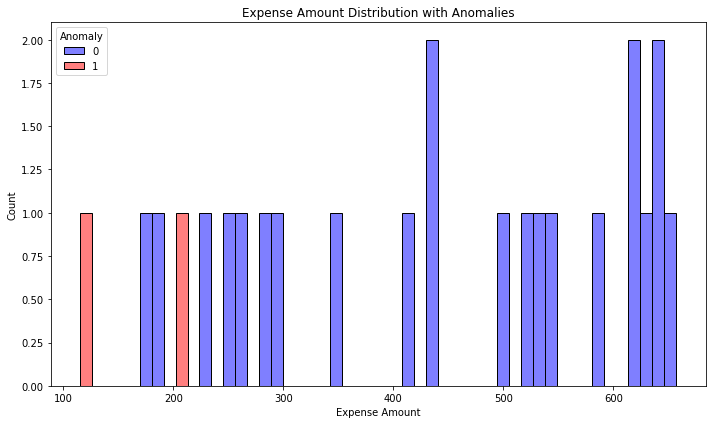

Total records: 24
Anomalies flagged: 2
         Date Department   Category  Amount  Anomaly  Anomaly_Score
10  1/11/2025   Children  Marketing  115.36        1       0.034621
20  1/21/2025       Home      Other  204.07        1       0.000095


In [65]:
run()

In [ ]:
#What It Does
#Cleans and encodes the dataset
#Scales numeric features
#Uses Isolation Forest to find outliers
#Flags unusual expense entries
#Outputs:
#Anomaly distribution plot (expense_anomalies_plot.png)